# Анализ цен на bmw
## 1. Overview
### Признаки:
* model: Модельный ряд
* year: Год регистрации
* price: Цена предложения в фунтах стерлингов
* transmission: Тип коробки передач (Automatic, Manual, Semi-Auto)
* mileage: Пробег в милях
* fuelType: Тип топлива (Diesel, Petrol, Hybrid, Other)
* tax: Дорожный налог
* mpg: Расход топлива (миль на галлон)
* engineSize: Объем двигателя в литрах

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_percentage_error, mean_absolute_error
from sklearn.model_selection import cross_val_score, train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from scipy.stats import kstest, norm
from collections import Counter
import warnings
from sklearn.preprocessing import LabelEncoder
!pip install category_encoders
from category_encoders import TargetEncoder

dataset = pd.read_csv('bmw.csv')
dataset.head()



,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,5 Series,2014,11200,Automatic,67068,Diesel,125,57.6,2.0
1,6 Series,2018,27000,Automatic,14827,Petrol,145,42.8,2.0
2,5 Series,2016,16000,Automatic,62794,Diesel,160,51.4,3.0
3,1 Series,2017,12750,Automatic,26676,Diesel,145,72.4,1.5
4,7 Series,2014,14500,Automatic,39554,Diesel,160,50.4,3.0


In [2]:
print(f"Размер датасета: {dataset.shape}")
print("Количество записей:\n", dataset.count())
print("\nСтатистика:\n", dataset.describe())
print("\nПропуски:\n", dataset.isnull().sum())
print("\nИнформация о датасете: ", dataset.info())


Размер датасета: (10781, 9)
Количество записей:
 model           10781
year            10781
price           10781
transmission    10781
mileage         10781
fuelType        10781
tax             10781
mpg             10781
engineSize      10781
dtype: int64

Статистика:
                year          price        mileage           tax           mpg  \
count  10781.000000   10781.000000   10781.000000  10781.000000  10781.000000   
mean    2017.078935   22733.408867   25496.986550    131.702068     56.399035   
std        2.349038   11415.528189   25143.192559     61.510755     31.336958   
min     1996.000000    1200.000000       1.000000      0.000000      5.500000   
25%     2016.000000   14950.000000    5529.000000    135.000000     45.600000   
50%     2017.000000   20462.000000   18347.000000    145.000000     53.300000   
75%     2019.000000   27940.000000   38206.000000    145.000000     62.800000   
max     2020.000000  123456.000000  214000.000000    580.000000    470.800000 

 ## 2. EDA и предобработка

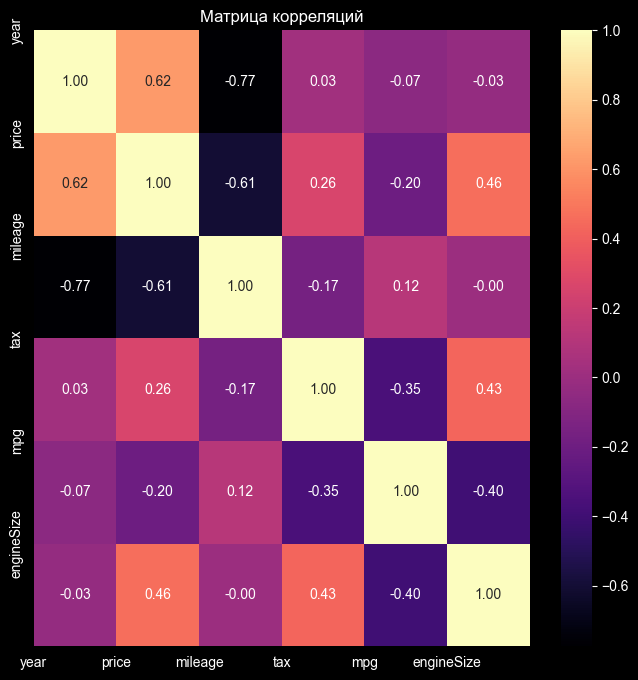

In [3]:
corr = dataset.corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(8, 8))
sns.heatmap(corr, cmap='magma', annot=True, fmt=".2f")
plt.xticks(range(len(corr.columns)), corr.columns)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Матрица корреляций")
plt.show()

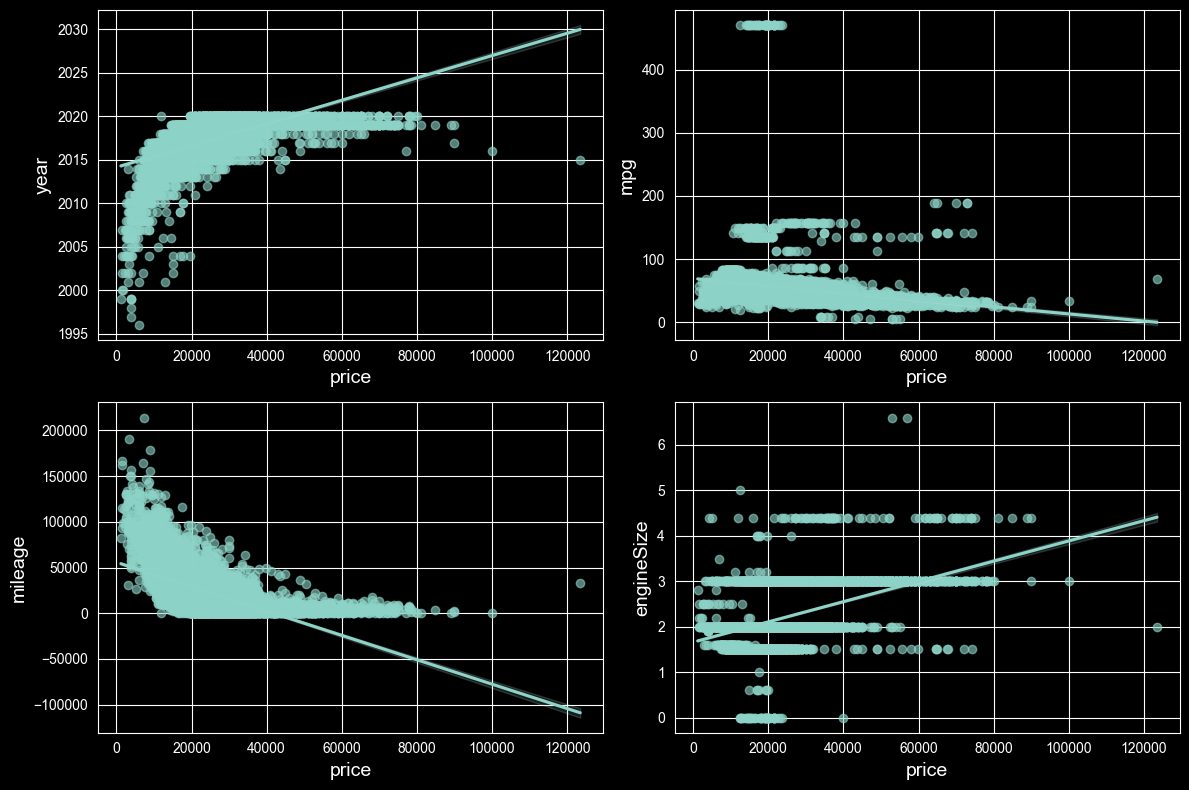

In [4]:
f, axes = plt.subplots(2, 2, figsize=(12,8))

sns.regplot(x='price', y='year', data=dataset, scatter_kws={'alpha':0.6}, ax=axes[0,0])
axes[0,0].set_xlabel('price', fontsize=14)
axes[0,0].set_ylabel('year', fontsize=14)

sns.regplot(x='price', y='mpg', data=dataset, scatter_kws={'alpha':0.6}, ax=axes[0,1])
axes[0,1].set_xlabel('price', fontsize=14)
axes[0,1].set_ylabel('mpg', fontsize=14)

sns.regplot(x='price', y='mileage', data=dataset, scatter_kws={'alpha':0.6}, ax=axes[1,0])
axes[1,0].set_xlabel('price', fontsize=14)
axes[1,0].set_ylabel('mileage', fontsize=14)

sns.regplot(x='price', y='engineSize', data=dataset, scatter_kws={'alpha':0.6}, ax=axes[1,1])
axes[1,1].set_xlabel('price', fontsize=14)
axes[1,1].set_ylabel('engineSize', fontsize=14)

plt.tight_layout()
plt.show()

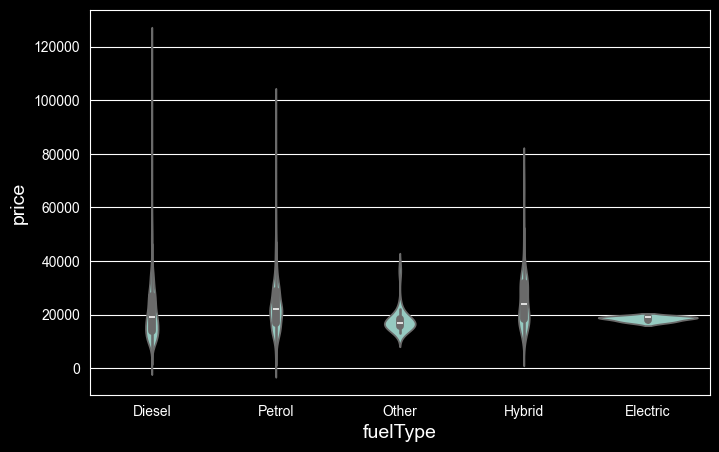

In [5]:
fuel_list= Counter(dataset['fuelType'])
labels = fuel_list.keys()
sizes = fuel_list.values()
fig, ax = plt.subplots(figsize=(8,5))
sns.violinplot(x='fuelType', y='price', data=dataset, ax=ax)
ax.set_xlabel('fuelType', fontsize=14)
ax.set_ylabel('price', fontsize=14)
plt.show()

In [6]:

dataset = pd.get_dummies(dataset, columns=['transmission', 'fuelType'])
dataset.head()

,model,year,price,mileage,tax,mpg,engineSize,transmission_Automatic,transmission_Manual,transmission_Semi-Auto,fuelType_Diesel,fuelType_Electric,fuelType_Hybrid,fuelType_Other,fuelType_Petrol
0,5 Series,2014,11200,67068,125,57.6,2.0,True,False,False,True,False,False,False,False
1,6 Series,2018,27000,14827,145,42.8,2.0,True,False,False,False,False,False,False,True
2,5 Series,2016,16000,62794,160,51.4,3.0,True,False,False,True,False,False,False,False
3,1 Series,2017,12750,26676,145,72.4,1.5,True,False,False,True,False,False,False,False
4,7 Series,2014,14500,39554,160,50.4,3.0,True,False,False,True,False,False,False,False


Очистила  названия моделей от пробелов. Для категорий transmission, fuelType с небольшим количеством вариантов применила One-Hot Encoding. Я поняла, что пробег и год главные факторы.Дизельные, бензиновые и гибридные BMW доминируют в высоком ценовом сегменте.

## 3.Работа с признаками

In [7]:
dataset['age'] = 2020 - dataset['year']
dataset['mileage_per_year'] = dataset['mileage'] / (dataset['age'] + 1)
columns_to_drop = ['year', 'fuelType', 'transmission']
dataset.drop(columns=[col for col in columns_to_drop if col in dataset.columns], inplace=True)

Я посчитала нужным заменить год выпуска на возраст, добавила интенсивность пробега, чтобы смотреть состояние машины.

## 4. Разделение выборки


In [8]:
X = dataset.drop('price', axis=1)
Y = dataset['price']
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)
print("Shape of X_train: ", X_train.shape)

X_train_encoded = X_train.copy()
X_test_encoded = X_test.copy()


model_means = y_train.groupby(X_train['model']).mean()
global_mean = y_train.mean()
X_train_encoded['model'] = X_train_encoded['model'].map(model_means)

X_test_encoded['model'] = X_test_encoded['model'].map(model_means).fillna(global_mean)

X_train_encoded.head()


Shape of X_train:  (8624, 15)


,model,mileage,tax,mpg,engineSize,transmission_Automatic,transmission_Manual,transmission_Semi-Auto,fuelType_Diesel,fuelType_Electric,fuelType_Hybrid,fuelType_Other,fuelType_Petrol,age,mileage_per_year
3652,22649.220118,9165,145,50.4,2.0,False,False,True,False,False,False,False,True,1,4582.500
7007,39407.904509,6650,145,37.7,3.0,True,False,False,True,False,False,False,False,1,3325.000
9045,22649.220118,64231,145,53.3,3.0,True,False,False,True,False,False,False,False,4,12846.200
3910,57374.153846,2799,135,141.2,1.5,True,False,False,False,False,True,False,False,1,1399.500
3635,39407.904509,63583,200,45.6,3.0,True,False,False,True,False,False,False,False,7,7947.875


Признак модель я закодировала с помощью Target Encoding. Я считаю, что он лучше подходит, так как позволил избежать приписывания моделям случайных порядковых номеров, предоставив алгоритму физически значимый показатель.

Я сделала так: 80% это обучающая выборка, 20% тестовая. Разделение выборки нужно для объективной оценки.Если модель учится и проверяется на одних и тех же данных, она может просто зазубрить цены для каждой конкретной записи, но при этом если изменить данные, то она провалится.

## 5. Обучение моделей


In [9]:
linear_steps = [
    ('poly', PolynomialFeatures(degree=2)),
    ('model', LinearRegression())
]
regressor_linear = Pipeline(linear_steps)
regressor_linear.fit(X_train_encoded, y_train)
y_pred_train = regressor_linear.predict(X_train_encoded)
y_pred_test = regressor_linear.predict(X_test_encoded)
r2_test = r2_score(y_test, y_pred_test)
r2_train = r2_score(y_train, y_pred_train)
mse = mean_squared_error(y_test, y_pred_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
mape = mean_absolute_percentage_error(y_test, y_pred_test)


print("Linear Regression Results:")
print('R2_score (test): ', r2_test)
print('R2_score (train): ', r2_train)
print("MSE: ", mse)
print("RMSE: ", rmse)
print("MAPE: ", mape)


Linear Regression Results:
R2_score (test):  0.9038743947211185
R2_score (train):  0.9163967756035911
MSE:  12430483.067731129
RMSE:  3525.6890202811605
MAPE:  0.10082823811056232


In [10]:
ridge_steps = [
    ('scalar', StandardScaler()),
    ('poly', PolynomialFeatures(degree=2)),
    ('model', Ridge())
]
ridge_pipe = Pipeline(ridge_steps)

ridge_param_grid = {'model__alpha': [0.1, 1.0, 10.0, 100.0, 500.0, 1000.0, 2000.0]}
ridge_grid = GridSearchCV(ridge_pipe, ridge_param_grid, cv=5, scoring='neg_mean_squared_error')
ridge_grid.fit(X_train_encoded, np.ravel(y_train))

best_ridge = ridge_grid.best_estimator_
print(f"Лучший параметр alpha для Ridge: {ridge_grid.best_params_['model__alpha']}")

y_pred_ridge_train = best_ridge.predict(X_train_encoded)
y_pred_ridge_test = best_ridge.predict(X_test_encoded)

r2_score_ridge_train = r2_score(y_train, y_pred_ridge_train)
r2_score_ridge_test = r2_score(y_test, y_pred_ridge_test)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge_test))
mape_ridge = mean_absolute_percentage_error(y_test, y_pred_ridge_test)


print("Ridge Regression Results:")
print(f"R2 Score (train): {r2_score_ridge_train:.4f}")
print(f"R2 Score (test): {r2_score_ridge_test:.4f}")
print(f"RMSE: {rmse_ridge:.2f}")
print(f"MAPE: {mape_ridge:.4f}")

Лучший параметр alpha для Ridge: 100.0
Ridge Regression Results:
R2 Score (train): 0.9147
R2 Score (test): 0.9032
RMSE: 3538.15
MAPE: 0.1006


In [11]:
lasso_steps = [
    ('poly', PolynomialFeatures(degree=2)),
    ('scalar', StandardScaler()),
    ('model', Lasso(max_iter=50000))
]
lasso_pipe = Pipeline(lasso_steps)

lasso_param_grid = {'model__alpha': [1.0, 5.0, 10.0, 50.0, 100.0, 500.0]}
lasso_grid = GridSearchCV(lasso_pipe, lasso_param_grid, cv=5, scoring='neg_mean_squared_error')
lasso_grid.fit(X_train_encoded, np.ravel(y_train))

best_lasso = lasso_grid.best_estimator_
print(f"Лучший параметр alpha для Lasso: {lasso_grid.best_params_['model__alpha']}")

y_pred_lasso_train = best_lasso.predict(X_train_encoded)
y_pred_lasso_test = best_lasso.predict(X_test_encoded)

r2_score_lasso_train = r2_score(y_train, y_pred_lasso_train)
r2_score_lasso_test = r2_score(y_test, y_pred_lasso_test)
rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso_test))
mape_lasso = mean_absolute_percentage_error(y_test, y_pred_lasso_test)

print("Lasso Regression Results:")
print(f"R2 Score (train): {r2_score_lasso_train:.4f}")
print(f"R2 Score (test): {r2_score_lasso_test:.4f}")
print(f"RMSE: {rmse_lasso:.2f}")
print(f"MAPE: {mape_lasso:.4f}")

Лучший параметр alpha для Lasso: 5.0
Lasso Regression Results:
R2 Score (train): 0.9145
R2 Score (test): 0.9038
RMSE: 3527.82
MAPE: 0.0992


In [12]:
models = [
    ('Linear Regression (Base)', rmse, mape, r2_test),
    ('Ridge (GridSearchCV)', rmse_ridge, mape_ridge, r2_score_ridge_test),
    ('Lasso (GridSearchCV)', rmse_lasso, mape_lasso, r2_score_lasso_test),
]

predict_df = pd.DataFrame(data=models, columns=['Model', 'RMSE', 'MAPE', 'R2_Score(test)'])
display(predict_df)

,Model,RMSE,MAPE,R2_Score(test)
0,Linear Regression (Base),3525.689020,0.100828,0.903874
1,Ridge (GridSearchCV),3538.152592,0.100615,0.903194
2,Lasso (GridSearchCV),3527.824731,0.099177,0.903758


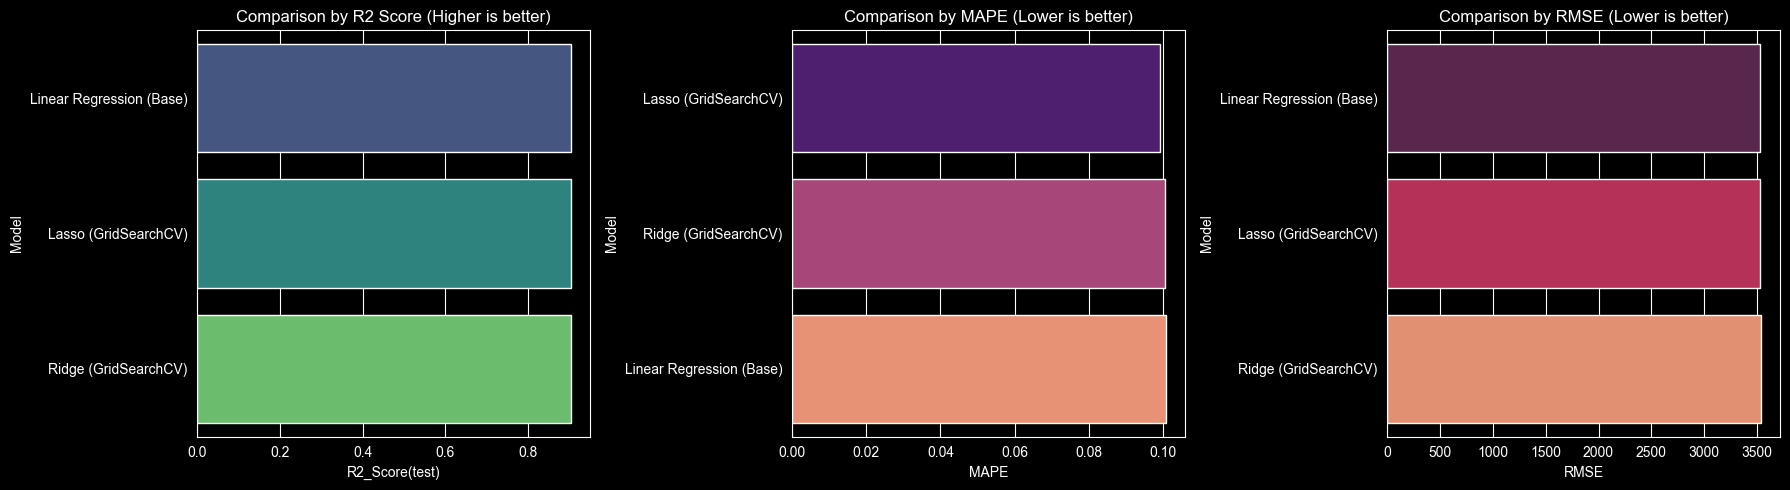

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(x='R2_Score(test)', y='Model', data=predict_df.sort_values('R2_Score(test)', ascending=False), ax=axes[0], palette='viridis', hue='Model', legend=False)
axes[0].set_title('Comparison by R2 Score (Higher is better)')

sns.barplot(x='MAPE', y='Model', data=predict_df.sort_values('MAPE'), ax=axes[1], palette='magma', hue='Model', legend=False)
axes[1].set_title('Comparison by MAPE (Lower is better)')

sns.barplot(x='RMSE', y='Model', data=predict_df.sort_values('RMSE'), ax=axes[2], palette='rocket', hue='Model', legend=False)
axes[2].set_title('Comparison by RMSE (Lower is better)')

plt.tight_layout()
plt.show()

Скорость обучения Ridge выше, так как её алгоритм стабильно работает с большим количеством колонок. Для Lasso потребовалось больще времени, чтобы прийти к результату, так как эта модель тратит дополнительные ресурсы на отбор самых важных признаков и удаление лишних.

* Я выбрала $R^2$, чтобы доказать общую точность модели, и RMSE, чтобы убедиться в отсутствии огромных ошибок в цене. Метрика MAPE добавлена для наглядности: она показывает, что средняя ошибка составляет всего 10%.
* Метрики считались на тестовой выборке.
* Лучше справилась Lasso, так как у неё самый низкий показатель ошибки MAPE (0.099), и при этом она сохраняет высокий коэффициент точности ($R^2$) и низкую денежную ошибку (RMSE). Это значит, что модель не только точная в среднем, но и стабильная, без резких скачков в прогнозах.
* Результаты можно считать хорошими: коэффициент $R^2$ выше 0.90 означает, что модель успешно объясняет более 90% причин изменения цены на автомобили. Средняя ошибка MAPE составила около 10%. Это подтверждает, что модель выявила реальные закономерности.


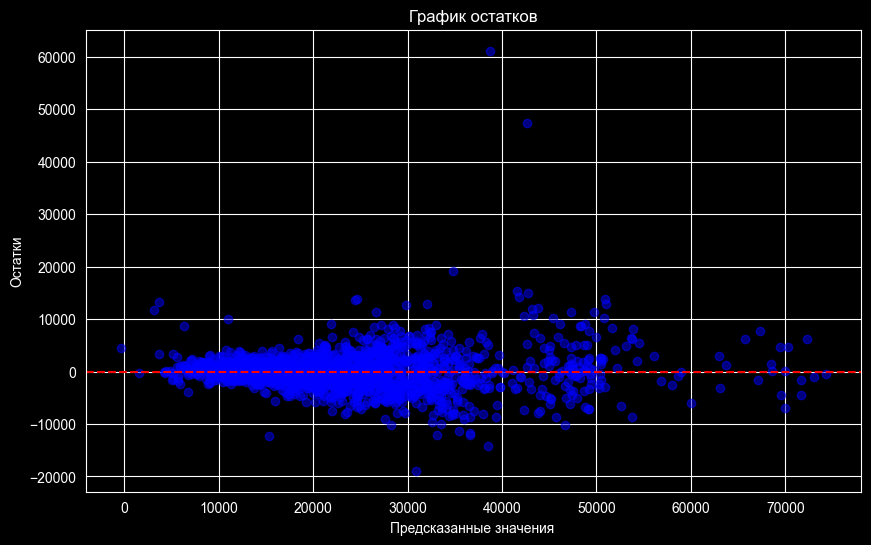

In [15]:
residuals = y_test - y_pred_lasso_test

plt.figure(figsize=(10, 6))
plt.scatter(y_pred_lasso_test, residuals, alpha=0.5, color='blue')
plt.axhline(y=0, color='red', linestyle='--')
plt.title('График остатков')
plt.xlabel('Предсказанные значения ')
plt.ylabel('Остатки')
plt.show()

График остатков показывает случайное распределение ошибок вокруг нуля без каких-либо видимых структур. Это прямое доказательство того, что модель полностью обучилась на реальных зависимостях и не переобучилась на случайных совпадениях.ы видим несколько точек далеко вверху . Модель не стала под них подстраиваться, сохранив точность для основной массы машин. Выполнение условий теоремы Гаусса-Маркова и игнорирование единичных выбросов подтверждают отсутствие переобучения.